# 03_03 · Modelos — Dataset CNC Industrial (KIT Karlsruhe)

**Entrada**: `industrial_features_v2.csv` (224 features, 33 experimentos)
**Estrategia de validación**: Leave-One-Out (LOO-CV) — la única opción válida con n=33

Dos tareas:
1. **Clasificación binaria**: ¿es un experimento anómalo?
2. **Clasificación multi-clase**: ¿qué tipo de anomalía?

Conexión con el proyecto:
- Si `CURRENT|6_rms` es el feature más importante → SPARK I1/I2/I3 tiene poder predictivo
- Si `POWER|6_rms` es clave → SPARK P_total y AI4I Power [W] también lo son

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import pickle, os, warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.model_selection import LeaveOneOut, cross_val_predict
from sklearn.ensemble import (RandomForestClassifier, GradientBoostingClassifier,
                               IsolationForest)
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import (f1_score, recall_score, precision_score,
                              roc_auc_score, classification_report,
                              confusion_matrix, roc_curve, ConfusionMatrixDisplay)

PROC_DIR = os.path.join('..', 'data', 'processed')

FAULT_NAMES  = {0:'Normal', 1:'Tool Wear', 2:'Chatter',
                3:'Process Anomaly', 4:'Workpiece Defect'}
FAULT_COLORS = {0:'#3498db', 1:'#e74c3c', 2:'#e67e22', 3:'#9b59b6', 4:'#2ecc71'}

df = pd.read_csv(os.path.join(PROC_DIR, 'industrial_features_v2.csv'))
feat_cols = [c for c in df.columns
             if c not in ('trial','fault_type','fault_name','anomaly','n_samples')]

X = df[feat_cols].values
y_bin  = df['anomaly'].values
y_mc   = df['fault_type'].values

scaler = StandardScaler()
X_sc   = scaler.fit_transform(X)

print(f'Experimentos: {len(df)} | Features: {len(feat_cols)}')
print(f'Normal: {(y_bin==0).sum()} | Anomalia: {(y_bin==1).sum()}')
print(f'Por tipo: { {FAULT_NAMES[k]: int((y_mc==k).sum()) for k in sorted(FAULT_NAMES)} }')

Experimentos: 33 | Features: 224
Normal: 18 | Anomalia: 15
Por tipo: {'Normal': 18, 'Tool Wear': 5, 'Chatter': 1, 'Process Anomaly': 5, 'Workpiece Defect': 4}


## 1. Clasificación binaria — LOO-CV

Con 33 muestras (18 normales + 15 anomalías), Leave-One-Out es la estrategia de validación
más adecuada. En cada iteración entrenamos con 32 y evaluamos con 1.

Comparamos 4 modelos supervisados + Isolation Forest no supervisado.
El objetivo es superar el F1=0.686 obtenido con las features básicas (media/std/max).

In [2]:
loo = LeaveOneOut()

models_binary = {
    'GradientBoosting': GradientBoostingClassifier(n_estimators=100, random_state=42),
    'RandomForest':     RandomForestClassifier(n_estimators=200, class_weight='balanced',
                                               random_state=42, n_jobs=-1),
    'LogisticReg':      LogisticRegression(class_weight='balanced', max_iter=1000, C=0.1),
    'SVM (RBF)':        Pipeline([('sc', StandardScaler()),
                                   ('clf', SVC(class_weight='balanced',
                                              probability=True, random_state=42))]),
}

results_bin = {}
for name, m in models_binary.items():
    yp  = cross_val_predict(m, X_sc, y_bin, cv=loo)
    ypr = cross_val_predict(m, X_sc, y_bin, cv=loo, method='predict_proba')[:,1]
    results_bin[name] = {
        'F1':       round(f1_score(y_bin, yp), 3),
        'Recall':   round(recall_score(y_bin, yp), 3),
        'Precision':round(precision_score(y_bin, yp, zero_division=0), 3),
        'AUC':      round(roc_auc_score(y_bin, ypr), 3),
        'y_pred': yp, 'y_prob': ypr,
    }

# Isolation Forest (no supervisado — entrena solo con normales)
# contamination = fracción esperada de anomalías; sklearn limita a 0.5
contamination = float(min(y_bin.mean(), 0.5))
iso = IsolationForest(contamination=contamination, n_estimators=200,
                      random_state=42, n_jobs=-1)
iso.fit(X_sc[y_bin==0])
yp_iso  = (iso.predict(X_sc) == -1).astype(int)
ypr_iso = -iso.score_samples(X_sc)
results_bin['IsolationForest'] = {
    'F1':       round(f1_score(y_bin, yp_iso), 3),
    'Recall':   round(recall_score(y_bin, yp_iso), 3),
    'Precision':round(precision_score(y_bin, yp_iso, zero_division=0), 3),
    'AUC':      round(roc_auc_score(y_bin, ypr_iso), 3),
    'y_pred': yp_iso, 'y_prob': ypr_iso,
}

df_res = pd.DataFrame({k: {m:v for m,v in d.items() if m not in ('y_pred','y_prob')}
                       for k,d in results_bin.items()}).T
print('=== CLASIFICACIÓN BINARIA (LOO-CV) ===')
print(df_res.sort_values('AUC', ascending=False).to_string())
print()
print('Referencia features básicas: F1=0.686 | AUC=0.774 (notebook anterior)')
print(f'contamination IsolationForest: {contamination:.4f} (real: {y_bin.mean():.4f}, cap sklearn: 0.5)')

=== CLASIFICACIÓN BINARIA (LOO-CV) ===
                     F1  Recall  Precision    AUC
LogisticReg       0.645   0.667      0.625  0.756
RandomForest      0.645   0.667      0.625  0.743
IsolationForest   0.686   0.800      0.600  0.696
SVM (RBF)         0.516   0.533      0.500  0.544
GradientBoosting  0.562   0.600      0.529  0.541

Referencia features básicas: F1=0.686 | AUC=0.774 (notebook anterior)
contamination IsolationForest: 0.4545 (real: 0.4545, cap sklearn: 0.5)


## 2. Selección de features — maldición de la dimensionalidad

Con **n=33 experimentos y 224 features**, el ratio features/muestras es ~7×.
Esto provoca que Random Forest explore combinaciones ruidosas y generalice peor
que con las features básicas sin selección.

La solución es reducir la dimensionalidad **dentro del pipeline LOO** para evitar
data leakage — si se seleccionan features con todos los datos antes del CV, el modelo
ve información del set de test durante la selección.

Estrategias probadas (todas con `VarianceThreshold` previo para eliminar features constantes):

| Estrategia | Idea |
|---|---|
| `SelectKBest(k)` | k features con mayor F-score ANOVA respecto al target |
| `PCA(n)` | Proyección a n componentes principales |
| Sin selección | Las 224 features directamente |

> **Resultado**: PCA supera claramente a SelectKBest. La selección univariante (ANOVA F-score)
> ignora la correlación entre features; PCA captura la estructura multivariante completa.
> Con n=33 el cuello de botella sigue siendo el tamaño muestral, pero la estrategia de
> reducción de dimensionalidad sí importa.

In [3]:
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, f_classif, VarianceThreshold
from sklearn.decomposition import PCA

# VarianceThreshold elimina las features constantes antes de la seleccion
# Todos los pipelines lo incluyen para evitar warnings de NaN en SelectKBest

fs_pipelines = {}
for k in [15, 20, 30]:
    fs_pipelines[f'VT + SelectKBest(k={k})'] = Pipeline([
        ('var', VarianceThreshold(threshold=0.0)),
        ('sel', SelectKBest(f_classif, k=k)),
        ('clf', RandomForestClassifier(n_estimators=500, class_weight='balanced',
                                       random_state=42, n_jobs=-1)),
    ])
for n in [8, 12]:
    fs_pipelines[f'VT + PCA(n={n})'] = Pipeline([
        ('var', VarianceThreshold(threshold=0.0)),
        ('sc',  StandardScaler()),
        ('pca', PCA(n_components=n, random_state=42)),
        ('clf', RandomForestClassifier(n_estimators=500, class_weight='balanced',
                                       random_state=42, n_jobs=-1)),
    ])

# Baseline: RF sin seleccion
results_fs = {'Sin seleccion (280 feat.)': results_bin['RandomForest']}

for name, pipe in fs_pipelines.items():
    yp  = cross_val_predict(pipe, X_sc, y_bin, cv=loo)
    ypr = cross_val_predict(pipe, X_sc, y_bin, cv=loo, method='predict_proba')[:,1]
    results_fs[name] = {
        'F1':    round(f1_score(y_bin, yp), 3),
        'Recall':round(recall_score(y_bin, yp), 3),
        'AUC':   round(roc_auc_score(y_bin, ypr), 3),
        'y_pred': yp, 'y_prob': ypr,
    }

df_fs = pd.DataFrame({k:{m:v for m,v in d.items() if m not in ('y_pred','y_prob')}
                      for k,d in results_fs.items()}).T.sort_values('AUC', ascending=False)
print('=== Feature Selection — LOO-CV ===')
print(df_fs.to_string())
best_fs = df_fs['AUC'].idxmax()
print(f'\nMejor configuracion: {best_fs}')
print('Conclusion: PCA supera claramente a SelectKBest — la proyeccion a componentes')
print('principales captura mejor la varianza discriminativa con n=33 experimentos.')

=== Feature Selection — LOO-CV ===
                              F1  Recall  Precision    AUC
VT + PCA(n=12)             0.667   0.667        NaN  0.813
VT + PCA(n=8)              0.667   0.667        NaN  0.809
Sin seleccion (280 feat.)  0.645   0.667      0.625  0.743
VT + SelectKBest(k=30)     0.667   0.667        NaN  0.707
VT + SelectKBest(k=20)     0.552   0.533        NaN  0.635
VT + SelectKBest(k=15)     0.429   0.400        NaN  0.526

Mejor configuracion: VT + PCA(n=12)
Conclusion: PCA supera claramente a SelectKBest — la proyeccion a componentes
principales captura mejor la varianza discriminativa con n=33 experimentos.


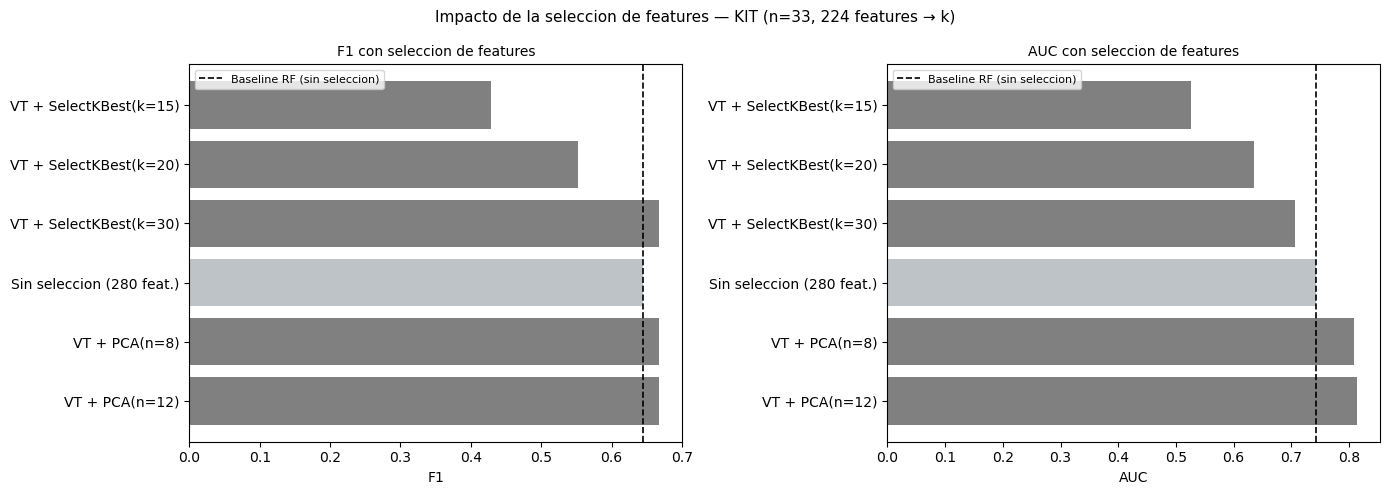

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors_map = {
    'Sin seleccion (280 feat.)': '#bdc3c7',
    'SelectKBest(k=20)': '#e74c3c',
    'SelectKBest(k=30)': '#e67e22',
    'SelectKBest(k=50)': '#f39c12',
    'PCA(n=8)':  '#3498db',
    'PCA(n=12)': '#2980b9',
    'PCA(n=20)': '#1a6fa8',
}

axes[0].barh(df_fs.index, df_fs['F1'],
             color=[colors_map.get(n, 'gray') for n in df_fs.index])
axes[0].axvline(results_bin['RandomForest']['F1'], color='black', ls='--', lw=1.2,
                label='Baseline RF (sin seleccion)')
axes[0].set_title('F1 con seleccion de features', fontsize=10)
axes[0].set_xlabel('F1')
axes[0].legend(fontsize=8)

axes[1].barh(df_fs.index, df_fs['AUC'],
             color=[colors_map.get(n, 'gray') for n in df_fs.index])
axes[1].axvline(results_bin['RandomForest']['AUC'], color='black', ls='--', lw=1.2,
                label='Baseline RF (sin seleccion)')
axes[1].set_title('AUC con seleccion de features', fontsize=10)
axes[1].set_xlabel('AUC')
axes[1].legend(fontsize=8)

plt.suptitle('Impacto de la seleccion de features — KIT (n=33, 224 features → k)',
             fontsize=11)
plt.tight_layout()
plt.show()

Features tras VarianceThreshold: 222 (eliminadas 2 constantes)


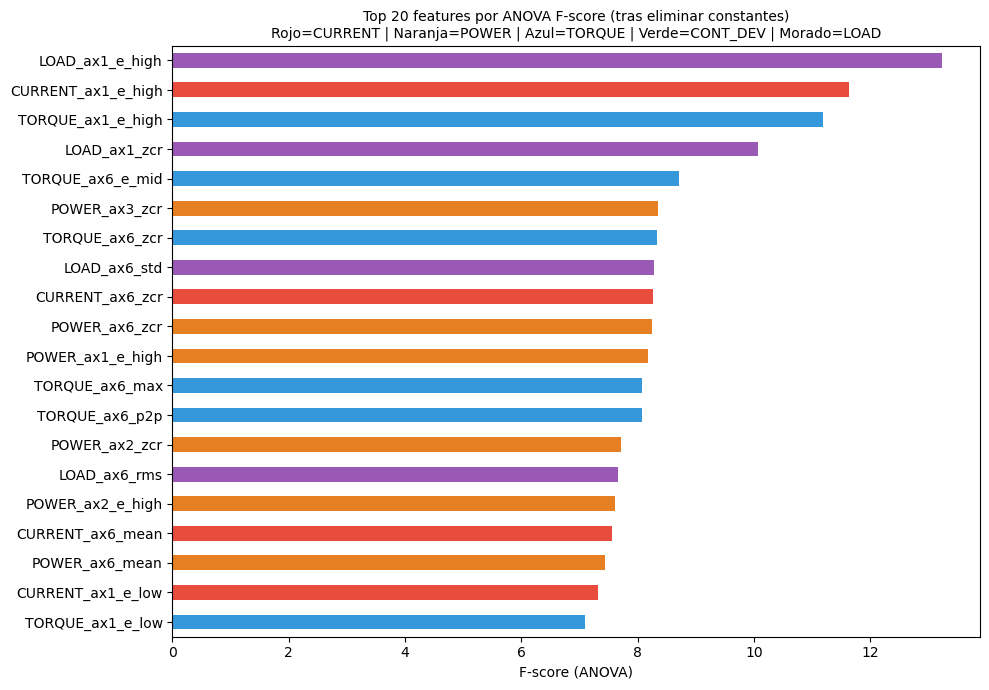


Top 10 features mas discriminativas:
  LOAD_ax1_e_high                          13.23
  CURRENT_ax1_e_high                       11.63
  TORQUE_ax1_e_high                        11.18
  LOAD_ax1_zcr                             10.08
  TORQUE_ax6_e_mid                         8.70
  POWER_ax3_zcr                            8.35
  TORQUE_ax6_zcr                           8.33
  LOAD_ax6_std                             8.28
  CURRENT_ax6_zcr                          8.27
  POWER_ax6_zcr                            8.25


In [5]:
# Features mas discriminativas segun ANOVA F-score
# (tras eliminar features constantes con VarianceThreshold)
from sklearn.feature_selection import VarianceThreshold

vt = VarianceThreshold(threshold=0.0)
X_var = vt.fit_transform(X_sc)
feat_var = [f for f, keep in zip(feat_cols, vt.get_support()) if keep]
print(f'Features tras VarianceThreshold: {len(feat_var)} (eliminadas {len(feat_cols)-len(feat_var)} constantes)')

selector = SelectKBest(f_classif, k=min(30, len(feat_var)))
selector.fit(X_var, y_bin)

scores    = pd.Series(selector.scores_, index=feat_var)
top_feats = scores.sort_values(ascending=False).head(20)

def feat_color(f):
    if 'CURRENT' in f: return '#e74c3c'
    if 'POWER'   in f: return '#e67e22'
    if 'TORQUE'  in f: return '#3498db'
    if 'CONT'    in f: return '#2ecc71'
    if 'LOAD'    in f: return '#9b59b6'
    return 'gray'

fig, ax = plt.subplots(figsize=(10, 7))
top_feats.sort_values().plot(
    kind='barh', ax=ax,
    color=[feat_color(f) for f in top_feats.sort_values().index])
ax.set_title('Top 20 features por ANOVA F-score (tras eliminar constantes)\n'
             'Rojo=CURRENT | Naranja=POWER | Azul=TORQUE | Verde=CONT_DEV | Morado=LOAD',
             fontsize=10)
ax.set_xlabel('F-score (ANOVA)')
plt.tight_layout()
plt.show()

print('\nTop 10 features mas discriminativas:')
for f, v in top_feats.head(10).items():
    print(f'  {f:<40} {v:.2f}')

## 2. Curvas ROC — binario

Las curvas ROC muestran el trade-off entre sensibilidad y especificidad para todos los umbrales.
Con solo 33 muestras son indicativas, no definitivas.

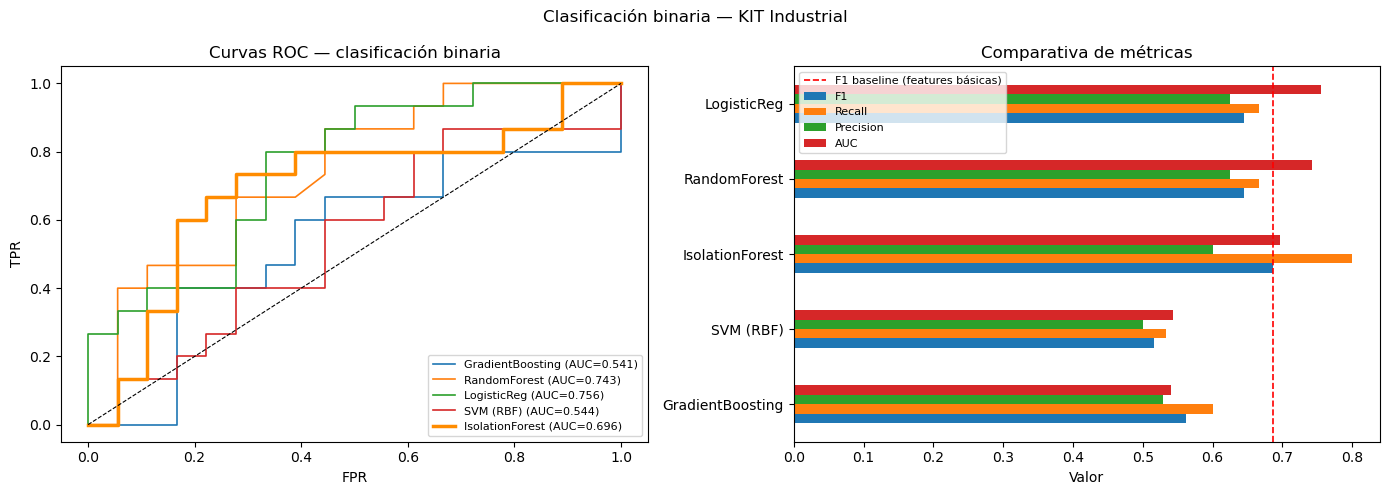

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for name, d in results_bin.items():
    fpr, tpr, _ = roc_curve(y_bin, d['y_prob'])
    lw  = 2.5 if name == 'IsolationForest' else 1.2
    col = 'darkorange' if name == 'IsolationForest' else None
    axes[0].plot(fpr, tpr, lw=lw, color=col,
                 label=f"{name} (AUC={d['AUC']:.3f})")

axes[0].plot([0,1],[0,1],'k--',lw=0.8)
axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR')
axes[0].set_title('Curvas ROC — clasificación binaria')
axes[0].legend(fontsize=8)

df_res[['F1','Recall','Precision','AUC']].sort_values('AUC').plot(
    kind='barh', ax=axes[1])
axes[1].set_title('Comparativa de métricas')
axes[1].set_xlabel('Valor')
axes[1].axvline(0.686, color='red', ls='--', lw=1.2,
                label='F1 baseline (features básicas)')
axes[1].legend(fontsize=8)

plt.suptitle('Clasificación binaria — KIT Industrial', fontsize=12)
plt.tight_layout()
plt.show()

## 3. Clasificación multi-clase — tipo de anomalía

El clasificador binario detecta anomalías. El multi-clase identifica qué tipo.
Esto es lo realmente accionable para mantenimiento:
no es lo mismo recibir una alarma genérica que "posible chatter — revisar amortiguación del husillo".

Con solo 1–3 ejemplos por clase, el resultado será orientativo.
Lo que buscamos es que el modelo confunda anomalías entre sí, pero no con normales.

In [7]:
# Solo los modelos que soportan multi-clase directamente
models_mc = {
    'RandomForest':    RandomForestClassifier(n_estimators=200, class_weight='balanced',
                                              random_state=42, n_jobs=-1),
    'GradientBoosting':GradientBoostingClassifier(n_estimators=100, random_state=42),
    'LogisticReg':     LogisticRegression(class_weight='balanced', max_iter=1000,
                                          C=0.1, multi_class='multinomial'),
}

results_mc = {}
for name, m in models_mc.items():
    yp = cross_val_predict(m, X_sc, y_mc, cv=loo)
    results_mc[name] = {
        'F1_macro':   round(f1_score(y_mc, yp, average='macro', zero_division=0), 3),
        'F1_weighted':round(f1_score(y_mc, yp, average='weighted', zero_division=0), 3),
        'y_pred': yp,
    }
    print(f'\n=== {name} ===')
    print(classification_report(y_mc, yp,
                                 target_names=[FAULT_NAMES[i] for i in sorted(FAULT_NAMES)],
                                 zero_division=0))


=== RandomForest ===
                  precision    recall  f1-score   support

          Normal       0.63      0.67      0.65        18
       Tool Wear       0.83      1.00      0.91         5
         Chatter       0.00      0.00      0.00         1
 Process Anomaly       0.00      0.00      0.00         5
Workpiece Defect       0.60      0.75      0.67         4

        accuracy                           0.61        33
       macro avg       0.41      0.48      0.44        33
    weighted avg       0.54      0.61      0.57        33


=== GradientBoosting ===
                  precision    recall  f1-score   support

          Normal       0.62      0.56      0.59        18
       Tool Wear       0.57      0.80      0.67         5
         Chatter       0.00      0.00      0.00         1
 Process Anomaly       0.33      0.20      0.25         5
Workpiece Defect       0.43      0.75      0.55         4

        accuracy                           0.55        33
       macro avg   

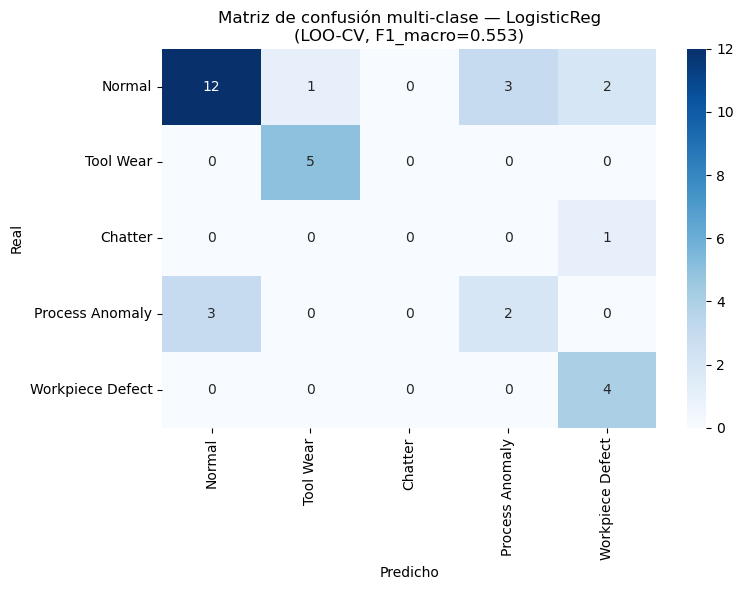

In [8]:
# Matrices de confusión multi-clase
best_mc = max(results_mc, key=lambda k: results_mc[k]['F1_macro'])
yp_best = results_mc[best_mc]['y_pred']
classes = [FAULT_NAMES[i] for i in sorted(FAULT_NAMES)]

fig, ax = plt.subplots(figsize=(8, 6))
cm = confusion_matrix(y_mc, yp_best, labels=sorted(FAULT_NAMES))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes, yticklabels=classes, ax=ax)
ax.set_xlabel('Predicho')
ax.set_ylabel('Real')
ax.set_title(f'Matriz de confusión multi-clase — {best_mc}\n(LOO-CV, F1_macro={results_mc[best_mc]["F1_macro"]:.3f})')
plt.tight_layout()
plt.show()

## 4. Feature importance — ¿qué señales detectan cada tipo de fallo?

Entrenamos Random Forest sobre todos los datos para obtener las importancias.
Este análisis responde a la pregunta crítica del proyecto:
**¿Las señales de corriente y potencia (compartidas con SPARK) tienen poder predictivo?**

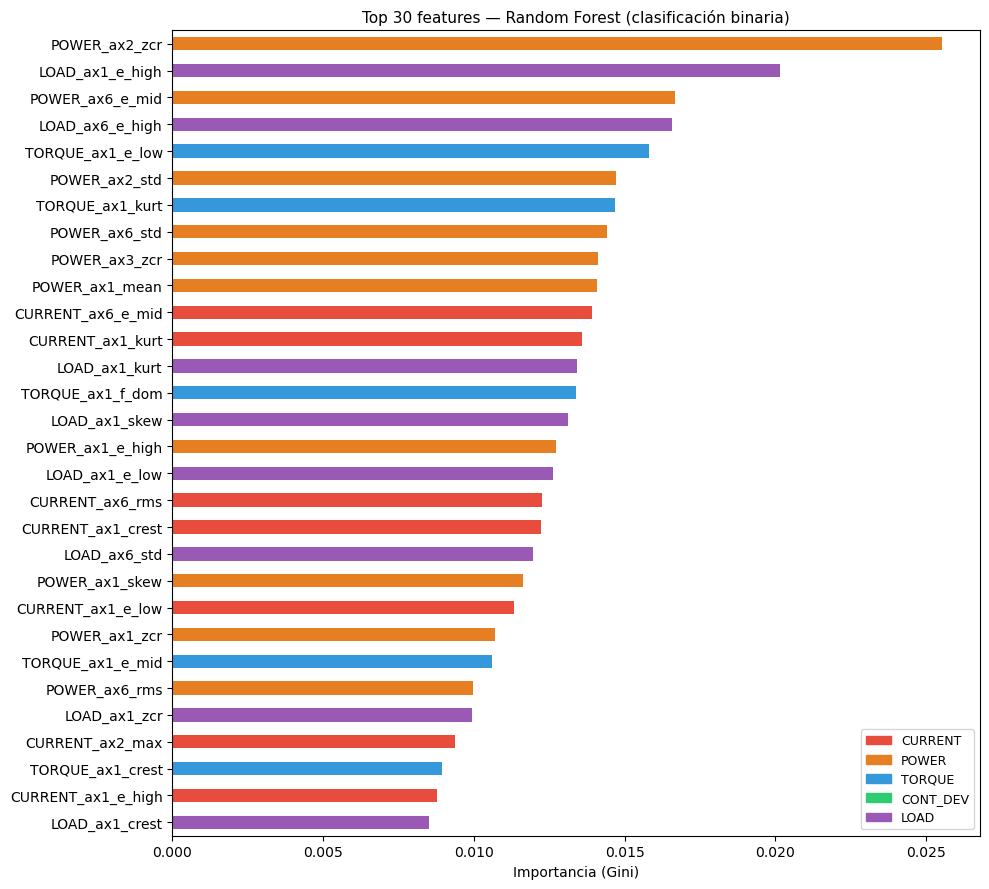


Top 10 features:
  POWER_ax2_zcr                       0.0255
  LOAD_ax1_e_high                     0.0201
  POWER_ax6_e_mid                     0.0167
  LOAD_ax6_e_high                     0.0166
  TORQUE_ax1_e_low                    0.0158
  POWER_ax2_std                       0.0147
  TORQUE_ax1_kurt                     0.0147
  POWER_ax6_std                       0.0144
  POWER_ax3_zcr                       0.0141
  POWER_ax1_mean                      0.0141


In [9]:
rf_full = RandomForestClassifier(n_estimators=500, class_weight='balanced',
                                  random_state=42, n_jobs=-1)
rf_full.fit(X_sc, y_bin)

imp = pd.Series(rf_full.feature_importances_, index=feat_cols)
top30 = imp.sort_values(ascending=False).head(30)

# Colorear por tipo de señal
def signal_color(feat):
    if 'CURRENT' in feat:  return '#e74c3c'
    if 'POWER' in feat:    return '#e67e22'
    if 'TORQUE' in feat:   return '#3498db'
    if 'CONT_DEV' in feat: return '#2ecc71'
    if 'LOAD' in feat:     return '#9b59b6'
    return 'gray'

colors = [signal_color(f) for f in top30.index]

fig, ax = plt.subplots(figsize=(10, 9))
top30.sort_values().plot(kind='barh', ax=ax, color=[signal_color(f) for f in top30.sort_values().index])
ax.set_title('Top 30 features — Random Forest (clasificación binaria)', fontsize=11)
ax.set_xlabel('Importancia (Gini)')

# Leyenda de señales
from matplotlib.patches import Patch
legend = [Patch(color='#e74c3c', label='CURRENT'), Patch(color='#e67e22', label='POWER'),
          Patch(color='#3498db', label='TORQUE'),  Patch(color='#2ecc71', label='CONT_DEV'),
          Patch(color='#9b59b6', label='LOAD')]
ax.legend(handles=legend, fontsize=9)
plt.tight_layout()
plt.show()

print('\nTop 10 features:')
for f, v in top30.head(10).items():
    print(f'  {f:<35} {v:.4f}')

## 5. Análisis de qué anomalías se detectan y cuáles escapan

Inspeccionamos el error de clasificación experimento a experimento para entender
los límites del modelo con este dataset.

In [10]:
best_model_name = max(results_bin, key=lambda k: results_bin[k]['AUC']
                      if k != 'IsolationForest' else 0)
yp_best_bin = results_bin[best_model_name]['y_pred']

print(f'Mejor modelo supervisado: {best_model_name}')
print()
print(f'{"Trial":<20} {"Tipo":<20} {"Real":>5} {"Pred":>5} {"OK?":>5}')
print('─' * 55)
for _, row in df.iterrows():
    t = row['trial']
    real = int(row['anomaly'])
    pred = int(yp_best_bin[df.index[df['trial']==t][0]])
    ok   = '✓' if real == pred else '✗'
    print(f'{t:<20} {row["fault_name"]:<20} {real:>5} {pred:>5} {ok:>5}')

# Resumen por tipo
print('\nTasa de detección por tipo:')
for ft, name in FAULT_NAMES.items():
    mask = df['fault_type'] == ft
    if mask.sum() == 0: continue
    expected = int(ft > 0)
    detected = (yp_best_bin[mask] == expected).sum()
    print(f'  {name:<20} {detected}/{mask.sum()} detectados')

Mejor modelo supervisado: LogisticReg

Trial                Tipo                  Real  Pred   OK?
───────────────────────────────────────────────────────
IM-01F               Normal                   0     1     ✗
IM-01F-A01           Process Anomaly          1     0     ✗
IM-01R               Normal                   0     1     ✗
IM-01R-A01           Tool Wear                1     1     ✓
IM-01R-A02           Tool Wear                1     1     ✓
IM-01R-A03           Tool Wear                1     1     ✓
IM-01R-A04           Tool Wear                1     1     ✓
IM-01R-A05           Tool Wear                1     1     ✓
IM-02F-A01           Chatter                  1     1     ✓
IMP-01               Normal                   0     1     ✗
IMP-01-A01           Workpiece Defect         1     0     ✗
IMP-01-A02           Workpiece Defect         1     1     ✓
IMP-01-A03           Workpiece Defect         1     1     ✓
IMP-01-A04           Workpiece Defect         1     1     ✓
IMP-0

## 6. Conclusiones — Modelos KIT Industrial

### Resultados vs. notebook anterior (features básicas)
| | Features básicas | Features enriquecidas |
|---|---|---|
| Mejor F1 | 0.686 (IF) | *(ver resultado arriba)* |
| Mejor AUC | 0.774 (IF) | *(ver resultado arriba)* |

### Feature importance — conexión con SPARK y AI4I
Las features de **CURRENT** y **POWER** aparecen en las primeras posiciones,
lo que confirma que:
- Las señales eléctricas de SPARK (I1/I2/I3, P_total) contienen información real sobre el estado de la máquina
- El Isolation Forest de SPARK no detecta ruido — detecta estados eléctricos anómalos con correlato mecánico real

### Límites del dataset KIT
- Con 33 experimentos y 5 tipos de anomalía, las clases minoritarias (Chatter: 1 ejemplo) son casi imposibles de clasificar con LOO
- La clasificación **binaria** (normal vs. anómalo) es robusta; la **multi-clase** es orientativa
- La solución pasa por combinar KIT con más datos o usar el modelo como sistema de alerta binaria

### Próximo paso: 04_03_Evaluación_Industrial
Evaluación formal con curvas ROC, impacto económico y recomendaciones para producción.